In [1]:
from pathlib import Path

import prism

from imagematerials.factory import ModelFactory, Sector
from imagematerials.model import (
    EndOfLife,
    GenericMaterials,
    GenericStocks,
    Maintenance,
    MaterialIntensities,
    RestOf
)
from imagematerials.preprocessing import get_preprocessing_data

from imagematerials.rest_of import rest_of_preprocessing


In [2]:
#load historic data
from imagematerials.rest_of.resource_model import ResourceModel

steel = ResourceModel(resource_group = 'metals', resource = 'steel', 
                        image_mat_available = True, start_year = 1971,
                        scenario="SSP2_M_CP",
                        convert_image=True, end_year = 2012, convert_to_tons = 1/1000_000, 
                        trade_data=True, path_input_data="../data/raw/rest-of", 
                        path_input_data_image = Path("../data/raw/image"))

aluminium = ResourceModel(resource_group = 'metals', resource = 'aluminium', 
                        image_mat_available = True, start_year = 1998, 
                        scenario="SSP2_M_CP", end_year = 2024, path_input_data="../data/raw/rest-of", 
                        path_input_data_image = Path("../data/raw/image")
                        )

cement = ResourceModel(resource_group = 'nmm', resource = 'cement', 
                    image_mat_available = True, start_year = 1971, 
                    scenario="SSP2_M_CP",
                    convert_image=True, end_year = 2012, convert_to_tons = 1/1000_000, 
                    trade_data=True, path_input_data="../data/raw/rest-of", 
                    path_input_data_image = Path("../data/raw/image"))

copper = ResourceModel(resource_group = 'metals', resource = 'copper', 
                       image_mat_available = True, start_year = 1990,
                       scenario= 'SSP2_M_CP', end_year = 2011,
                       path_input_data="../data/raw/rest-of", 
                       path_input_data_image = Path("../data/raw/image"))


In [3]:
image_scenario = "SSP2_M_CP"
climate_policy_scenario_dir = Path("..", "data", "raw", "image", image_scenario)

In [4]:
scenario_base_path = Path("../data/raw") / 'circular_economy_scenarios'

# Define the complete timeline, including historic tail
# time_start = prep_data["stocks"].coords["Time"].min().values
time_start = 1960
complete_timeline = prism.Timeline(time_start, 2100, 1)
simulation_timeline = prism.Timeline(1970, 2100, 1)


bld_sector = get_preprocessing_data("buildings", Path("..", "data", "raw"), 
                                    climate_policy_scenario_dir, 
                                    circular_economy_scenario_dirs = None) 
vhc_sector = get_preprocessing_data("vehicles", Path("..", "data", "raw"), 
                                    climate_policy_scenario_dir, 
                                    circular_economy_scenario_dirs = None)
rest_sector = rest_of_preprocessing(Path("..", "data", "raw"), 
                    image_scenario_directory = climate_policy_scenario_dir)

# TODO fix this for real in the future
prep_data = vhc_sector.prep_data

vhc_sector = Sector('vehicles', prep_data)
rest_sector = Sector(name='rest_of', 
                    data = rest_sector,)

factory = ModelFactory(
[bld_sector, vhc_sector, rest_sector], complete_timeline
).add(GenericStocks, ["buildings", "vehicles"]
).add(GenericMaterials,  "vehicles"
).add(MaterialIntensities, "buildings",
).add(RestOf, "rest_of", input_sources={
    "gompertz_coefs": "rest_of",
    "gdp_per_capita": "rest_of",
    "population": "rest_of",
    "historic_diff_consumption": "rest_of"
}
)
model = factory.finish()

import warnings
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    model.simulate(simulation_timeline)



c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\indexing.py:1689: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


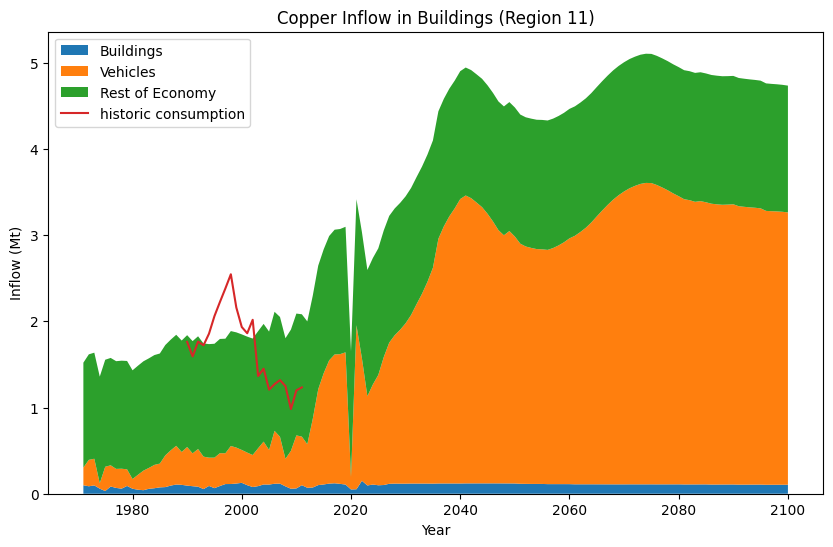

In [10]:
# stack plot of material inflow in buildings and vehicles
from imagematerials.rest_of.const import COPPER_AVERAGE_REGIONS_TO_IMAGE, IAI_TO_IMAGE_CLASSES
COPPER_AVERAGE_REGIONS_TO_IMAGE


material_sel = "Copper"
# all_regions = list(range(1, 27))
region_sel = "11"
import matplotlib.pyplot as plt

inflow_buildings = model.buildings.get('inflow_materials').to_array().sel(material = material_sel, Region = region_sel).sum(["Type"]).loc[1971:].pint.to("Mt")
inflow_vehicles = model.vehicles.get('inflow_materials').to_array().sel(material = 'Cu', Region = region_sel).sum(["Type"]).loc[1971:].pint.to("Mt")
inflow_rest = model.rest_of.get('inflow_materials_rest').sel(material = material_sel, Region = region_sel).loc[1971:].rename({'Time': 'time'}).pint.to("Mt")
years = inflow_buildings.coords['time'].values

historic_consumption_data = copper.historic_consumption_data.loc[:, f"class_ {region_sel}"] / 1e6

fig, ax = plt.subplots(figsize=(10, 6))
ax.stackplot(years, inflow_buildings, inflow_vehicles, inflow_rest, labels=['Buildings', 'Vehicles', 'Rest of Economy'])
historic_consumption_data.plot(label = "historic consumption")


ax.set_title(f'{material_sel} Inflow in Buildings (Region {region_sel})')
ax.set_xlabel('Year')
ax.set_ylabel('Inflow (Mt)')
ax.legend(loc='upper left')
plt.show()


c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


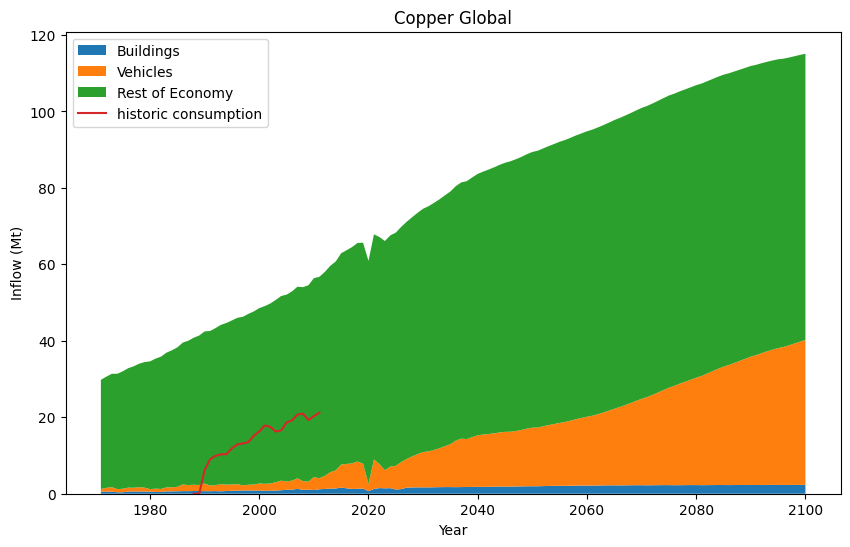

In [6]:
# stack plot of material inflow in buildings and vehicles
material_sel = "Copper"
all_regions = list(range(1, 27))

import matplotlib.pyplot as plt

inflow_buildings = model.buildings.get('inflow_materials').to_array().sel(material = material_sel).pint.to("Mt").sum(["Type", "Region"]).loc[1971:]
inflow_vehicles = model.vehicles.get('inflow_materials').to_array().sel(material = "Cu").pint.to("Mt").sum(["Type", "Region"]).loc[1971:]
inflow_rest = model.rest_of.get('inflow_materials_rest').sel(material = material_sel).pint.to("Mt").loc[1971:].sum(["Region"]).rename({'Time': 'time'}).loc[:]
years = inflow_buildings.coords['time'].values

historic_consumption_data = copper.historic_consumption_data.sum(axis = 1) / 1e6

fig, ax = plt.subplots(figsize=(10, 6))
ax.stackplot(years, inflow_buildings, inflow_vehicles, inflow_rest, labels=['Buildings', 'Vehicles', 'Rest of Economy'])
historic_consumption_data.plot(label = "historic consumption")


ax.set_title(f'{material_sel} Global')
ax.set_xlabel('Year')
ax.set_ylabel('Inflow (Mt)')
ax.legend(loc='upper left')
plt.show()

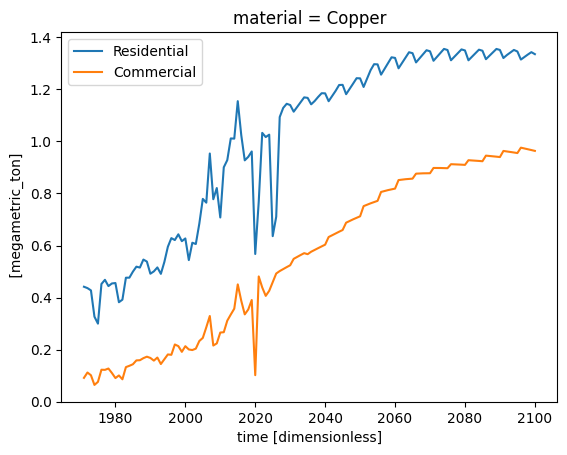

In [7]:
inflow_buildings = model.buildings.get('inflow_materials').to_array().sel(material = material_sel,
                                                                          Type = ['Appartment - Rural', 'Appartment - Urban', 'Detached - Rural',
       'Detached - Urban', 'High-rise - Rural', 'High-rise - Urban',
       'Semi-detached - Rural', 'Semi-detached - Urban']).pint.to("Mt").sum(["Region", "Type"]).loc[1971:]

inflow_buildings_com = model.buildings.get('inflow_materials').to_array().sel(material = material_sel,
                                                                          Type = ['Office', 'Retail+',
       'Hotels+', 'Govt+']).pint.to("Mt").sum(["Region", "Type"]).loc[1971:]


inflow_buildings.plot(label = "Residential")
inflow_buildings_com.plot(label = "Commercial")

plt.legend()

In [8]:
# sum inflow materials for steel, sum also per types keep regions and year

materials_dict_metal = {
    'Steel' : 'Steel',
    'Aluminium' : 'Aluminium',
    'Copper' : 'Cu',
}

materials_dict_nmm = {
    'Cement' : 'Cement',
    'Sand' : 'Sand'
}

# Conversion factors
# always taking the lower range numbers to be cautios

# https://civiltoday.com/civil-engineering-materials/cement/10-cement-ingredients-with-functions
# Cement: Lime 60-75%, Silica 17-25%, other aggregates
# https://concretesupplyco.com/concrete-basics/
# Concrete:  10% cement, 20% air and water, 30% sand, and 40% gravel --> 30% + 40% = 70%
# https://samsa.org.uk/key_uses/glass.php, https://www.carmeuse.com/na-en/references/case-studies-success-stories/limestone-glassmaking-what-you-need-know
# Sand (silica) in glass: 70%, lime: 15%

cement_in_concrete = 0.1
sand_in_cement_conversion = 0.17 #(silica)
sand_gravel_in_concrete_conversion = 0.7
sand_in_glass_conversion = 0.7

only_buildings = ['Cement', 'Concrete']
only_vehicles = ['Glass']
not_in_any = ['Sand']

def sum_inflows_for_output(materials_dict, resource_group):
    for key, value in materials_dict.items():
        print(key)
        if key not in only_buildings and key not in only_vehicles and not key in not_in_any:
            inflow_buildings = model.buildings.get('inflow_materials').to_array().sum(['Type']).sel(material=key).loc[1961:]
            inflow_vehicles = model.vehicles.get('inflow_materials').to_array().sum(['Type']).sel(material=value).loc[1961:]
            total_material = inflow_buildings + inflow_vehicles
        if key == 'Cement':
            # add concrete to cement
            inflow_buildings_cement = model.buildings.get('inflow_materials').to_array().sum(['Type']).sel(material=key).loc[1961:]
            inflow_buildings_concrete = model.buildings.get('inflow_materials').to_array().sum(['Type']).sel(material='Concrete').loc[1961:] * cement_in_concrete
            total_material = inflow_buildings_cement + inflow_buildings_concrete
        if key == 'Sand':
            inflow_buildings_cement_sand = model.buildings.get('inflow_materials').to_array().sum(['Type']).sel(material='Cement').loc[1961:]*sand_in_cement_conversion
            inflow_buildings_concrete_sand_via_cement = model.buildings.get('inflow_materials').to_array().sum(['Type']).sel(material='Concrete').loc[1961:] * cement_in_concrete * sand_in_cement_conversion
            inflow_buildings_sand_in_concrete = model.buildings.get('inflow_materials').to_array().sum(['Type']).sel(material='Concrete').loc[1961:] * sand_gravel_in_concrete_conversion
            inflow_vehicles_sand = model.vehicles.get('inflow_materials').to_array().sum(['Type']).sel(material='Glass').loc[1961:] * sand_in_glass_conversion
            total_material = inflow_buildings_cement_sand + inflow_buildings_concrete_sand_via_cement + inflow_buildings_sand_in_concrete + inflow_vehicles_sand

        # from total_material create a csv that has the years as rows and regions as columns, mae sure that region names are no just '1' but 'class_ 1'
        # also drop material dimension
        if key not in ['Copper', 'Cement', 'Sand']:
            total_material = total_material.drop_vars('material')
        # change the region coordinate so that it is class_ 1 instead of 1 , ...
        # Get the current region values
        regions = total_material.coords['Region'].values

        # Create new region names
        new_regions = [f'class_ {r}' for r in regions]

        # Assign the new region names to the coordinate
        total_material = total_material.assign_coords(Region=new_regions)
        # to t
        total_material = total_material.pint.to('t')
        # save as pandas to save as csv
        total_material = total_material.rename("total_material")
        # write key with a small letter
        key = key.lower()
        # to pandas
        total_material = total_material.to_dataframe().unstack()
        # drop unessecary column level index
        total_material.columns = total_material.columns.droplevel(0)
        # save as csv
        if key == 'sand':
            key = 'sand_gravel_crushed_rock'
            total_material = total_material.loc[1971:]
        else: 
            pass
        total_material.to_csv(f'../data/raw/rest-of/{resource_group}/image_materials_{key}.csv')
        print('done', key)
        
    return total_material


total_material_metals = sum_inflows_for_output(materials_dict_metal, 'metals')
total_material_nmm = sum_inflows_for_output(materials_dict_nmm, 'nmm')



Steel
done steel
Aluminium
done aluminium
Copper
done copper
Cement
done cement
Sand
done sand_gravel_crushed_rock


c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: Uni